In [121]:
import matplotlib.pyplot as plt
import numpy as np
from stillib_plotting import save, use_style, despine
from stillib_random import from_seed

from mscthesis.core.io import load_dataframe
from mscthesis.config import ProjectConfig 
from mscthesis.paths import ProjectPaths

use_style() 

knauer_raw = load_dataframe("/home/andreasstillits/coding/MasterThesis/scripts/data/raw/gm_dataset_Knauer_et_al_2022.csv")
knauer_filtered = load_dataframe("/home/andreasstillits/coding/MasterThesis/scripts/data/derived/Knauer_filtered.csv")
devi = load_dataframe("/home/andreasstillits/coding/MasterThesis/scripts/data/raw/devi_and_reddy_2018.csv")

root = from_seed(123456)


## Plug geometries

Number of sd measurements: 20
Number of samples drawn: 10000
Number of L measurements: 175
Plug radii per L value: 57.14


(0.0, 1.0)

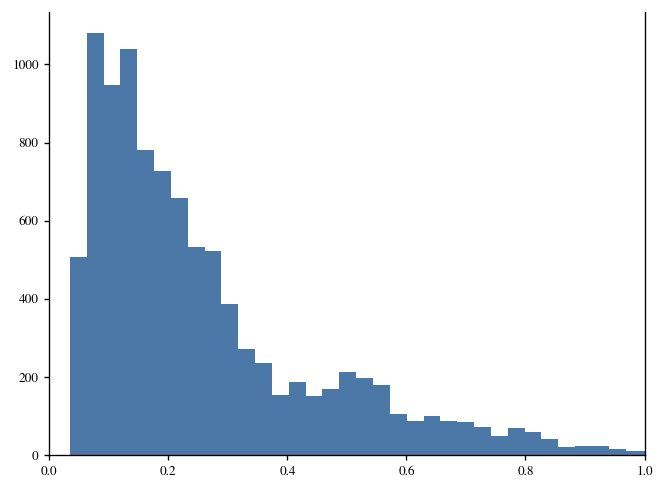

In [122]:
sd = np.zeros(len(devi) * 2)
sd_err = np.zeros(len(devi) * 2)
sd[0::2] = devi["SD low VPD"].to_numpy()
sd[1::2] = devi["SD high VPD"].to_numpy()
sd_err[0::2] = devi["SD low VPD error"].to_numpy()
sd_err[1::2] = devi["SD high VPD error"].to_numpy()

def draw_values(rng: np.random.Generator, mean: float, std: float, n: int, positive: bool = True) -> np.ndarray:
    """Draw n positive values from a normal distribution"""
    values = np.zeros(n) 
    index = 0
    while index < n:
        value = rng.normal(loc=mean, scale=std)
        if not positive or value > 0:
            values[index] = value
            index += 1
    return np.array(values)

def estimate_distribution(rng: np.random.Generator, means: np.ndarray, stds: np.ndarray, n_samples: int) -> np.ndarray:
    """Given a set of mean,std pairs, draw n_samples from each distribution and return as a single array"""
    data = np.zeros(len(means) * n_samples)
    index = 0
    for mean, std in zip(means, stds, strict=True):
        samples = draw_values(rng, mean, std, n_samples)
        data[index : index + n_samples] = samples
        index += n_samples
    return data

# estimate sd distribution from quotes values with errors

sd_stream = root.spawn("sd_stream")
sd_distribution = estimate_distribution(sd_stream.generator(), sd, sd_err, n_samples=500)
print(f"Number of sd measurements: {len(sd)}")
print(f"Number of samples drawn: {len(sd_distribution)}")
# translate to a plug radius distribution 

area_per_stoma = 1 / sd_distribution # mm2
plug_radius_distribution = 1000 * np.sqrt(area_per_stoma / np.pi) #µm

# Pair each plug radius with a random L value drawn from the Knauer dataset
L_stream = root.spawn("L_stream")
L = knauer_filtered["L"].to_numpy()
L_distribution = L_stream.generator().choice(L, size=plug_radius_distribution.size, replace=True)
print(f"Number of L measurements: {len(L)}")
print(f"Plug radii per L value: {len(plug_radius_distribution) / len(L):.2f}")

plug_aspect_distribution = plug_radius_distribution / L_distribution


plt.hist(plug_aspect_distribution, bins=100)
plt.xlim(0, 1)

Number of AL measurements: 20
Number of samples drawn: 10000
Stomatal radius per L value: 57.14


(0.0, 0.2)

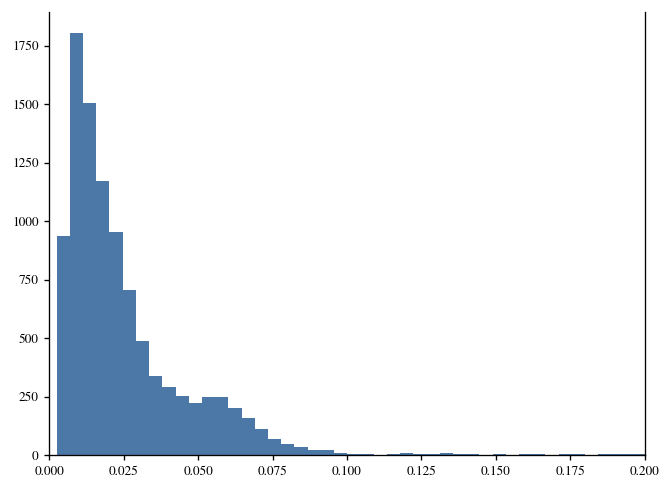

In [123]:
# Combine AL and AW into single arrays
al = np.zeros(len(devi) * 2)
al_err = np.zeros(len(devi) * 2)
aw = np.zeros(len(devi) * 2)
aw_err = np.zeros(len(devi) * 2)
al[0::2] = devi["AL low VPD"].to_numpy()
al[1::2] = devi["AL high VPD"].to_numpy()
al_err[0::2] = devi["AL low VPD error"].to_numpy()
al_err[1::2] = devi["AL high VPD error"].to_numpy()
aw[0::2] = devi["AW low VPD"].to_numpy()
aw[1::2] = devi["AW high VPD"].to_numpy()
aw_err[0::2] = devi["AW low VPD error"].to_numpy()
aw_err[1::2] = devi["AW high VPD error"].to_numpy()

print(f"Number of AL measurements: {len(al)}")

al_distribution = estimate_distribution(root.spawn("al_stream").generator(), al, al_err, n_samples=500)
aw_distribution = estimate_distribution(root.spawn("aw_stream").generator(), aw, aw_err, n_samples=500)
area_distribution = np.pi * al_distribution * aw_distribution / 4 # µm2
stomatal_radius_distribution = np.sqrt(area_distribution / np.pi) # µm

print(f"Number of samples drawn: {len(stomatal_radius_distribution)}")
print(f"Stomatal radius per L value: {len(stomatal_radius_distribution) / len(L):.2f}")

L_stream2 = root.spawn("L_stream2")
L_distribution2 = L_stream2.generator().choice(L, size=plug_radius_distribution.size, replace=True)

stomatal_aspect_distribution = stomatal_radius_distribution / L_distribution2

plt.hist(stomatal_aspect_distribution, bins=50)
plt.xlim(0, 0.2)


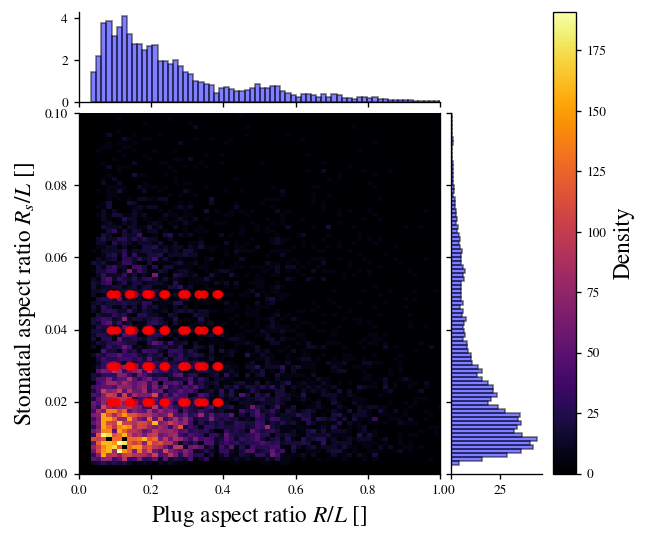

In [128]:
# Make a 2D heatmap of stomatal aspect ratio vs plug aspect ratio
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(6, 5))
gs = GridSpec(
    2, 2, 
    width_ratios=[4, 1], 
    height_ratios=[1, 4], 
    wspace=0.05, 
    hspace=0.05
)

ax_main = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_main)
ax_histx.tick_params(labelbottom=False)
ax_histy.tick_params(labelleft=False)
despine(ax_histx)
despine(ax_histy)


h = ax_main.hist2d(plug_aspect_distribution, stomatal_aspect_distribution, density=True, bins=200, cmap="inferno", cmax=200)
ax_main.set_xlabel(r"Plug aspect ratio $R/L$ []", fontsize=14)
ax_main.set_ylabel(r"Stomatal aspect ratio $R_s/L$ []", fontsize=14)
ax_main.set_facecolor("black")
# fig.colorbar(h[3], ax=ax_main, pad=0.02, label="Density")
ax_main.set_xlim(0, 1)
ax_main.set_ylim(0, 0.1)
#
ax_histx.hist(plug_aspect_distribution, bins=200, density=True, color="blue", alpha=0.5, edgecolor="black")
ax_histx.set_xlim(0, 1)
ax_histy.hist(stomatal_aspect_distribution, bins=200, density=True, color="blue", alpha=0.5, orientation='horizontal', edgecolor="black")
ax_histy.set_ylim(0, 0.1)

paths = ProjectPaths(ProjectConfig().behavior.storage_root)
diffusion = load_dataframe(paths.diffusion_index.require())
sim = diffusion[diffusion["stomatal_aspect"] < diffusion["plug_aspect"]]
ax_main.scatter(sim["plug_aspect"], sim["stomatal_aspect"], c="red", alpha=0.5, label="Simulated Samples")

cbar = fig.colorbar(h[3], pad=0.02, ax=[ax_main, ax_histx, ax_histy])
cbar.set_label("Density", fontsize=14)

save(fig, "./plug_geometry.pdf")
plt.show()

## Cell distribution

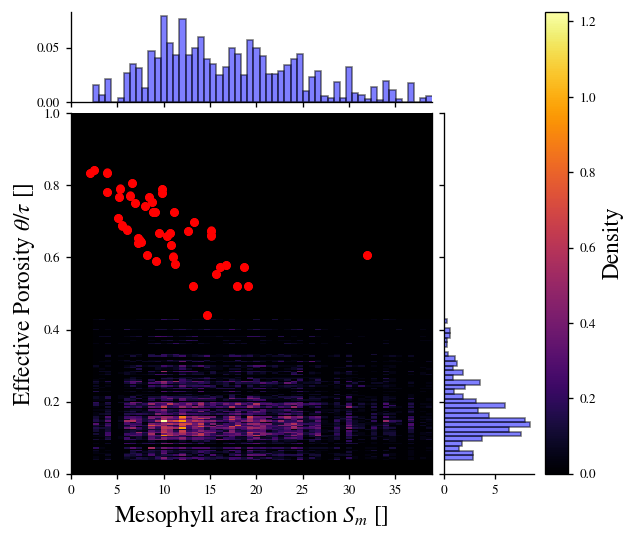

In [125]:
porosities = knauer_raw["fias_mesophyll"].to_numpy()
porosities = porosities[(~np.isnan(porosities)) & (porosities > 0)]

sms = knauer_raw["Sm"].to_numpy()
sms = sms[~np.isnan(sms)]

p_stream = root.spawn("p_stream")
porosity_distribution = p_stream.generator().choice(porosities, size=10000, replace=True) / 1.57

s_stream = root.spawn("s_stream")
sm_distribution = s_stream.generator().choice(sms, size=10000, replace=True)


fig = plt.figure(figsize=(6, 5))
gs = GridSpec(
    2, 2, 
    width_ratios=[4, 1], 
    height_ratios=[1, 4], 
    wspace=0.05, 
    hspace=0.05
)

ax_main = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_main)
ax_histx.tick_params(labelbottom=False)
ax_histy.tick_params(labelleft=False)
despine(ax_histx)
despine(ax_histy)


h = ax_main.hist2d(sm_distribution, porosity_distribution, density=True, bins=100, cmap="inferno")
ax_main.set_facecolor("black")
ax_main.set_xlabel(r"Mesophyll area fraction $S_m$ []", fontsize=14)
ax_main.set_ylabel(r"Effective Porosity $\theta/\tau$ []", fontsize=14)
ax_main.set_xlim(0, 39)
ax_main.set_ylim(0, 1.0)
#
ax_histx.hist(sm_distribution, bins=100, density=True, color="blue", alpha=0.5, edgecolor="black")
ax_histx.set_xlim(0, 39)
ax_histy.hist(porosity_distribution, bins=30, density=True, color="blue", alpha=0.5, orientation='horizontal', edgecolor="black")
ax_histy.set_ylim(0, 1.0)

paths = ProjectPaths(ProjectConfig().behavior.storage_root)
diffusion = load_dataframe(paths.diffusion_index.require())
ax_main.scatter(diffusion["mesophyll_area_fraction"], (1/diffusion["tomas"])/2, c="red", label="Simulated Samples", zorder=3)

cbar = fig.colorbar(h[3], pad=0.02, ax=[ax_main, ax_histx, ax_histy])
cbar.set_label("Density", fontsize=14)

save(fig, "./cell_geometry.pdf")
plt.show()

